In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import json

# load project modules
from song_recommender.paths import *
from song_recommender.utils import load_config

# Train/test/validation split

In [2]:
df = pd.read_parquet(DATA_DIR / 'metadata.parquet')
df.sample(5)

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,tempo,time_signature,crude_genre,duration_min,clip_duration,deezer_name,deezer_artist,isrc,deezer_tags,deezer_year
1025,TRNFVBM128F425DD55,Boring Machines Disturbs Sleep,Mogwai,https://p.scdn.co/mp3-preview/fa920324df1c60f3...,0JCeCIBS03gLA3rkEfZdGj,"ambient, experimental, instrumental, post_rock...",Rock,2003,185000,0.146,...,66.037,3,rock,3.083333,10.0,Boring Machines Disturbs Sleep,Mogwai,GBENL0300088,alternative,2003
8229,TRXLXET128F425E4FD,Gravemakers & Gunslingers,Coheed and Cambria,https://p.scdn.co/mp3-preview/b0dbdb6862668b94...,076jwGvRQpa8vVdsRLy1eV,progressive_rock,NaN,2007,260653,0.415,...,164.960,4,rock,4.344217,10.0,Gravemakers & Gunslingers,Coheed and Cambria,USSM10704117,alternative,2007
4958,TRWVKDP128F4247DAF,Break You Off,The Roots,https://p.scdn.co/mp3-preview/81a98ab3fa74f4b0...,09TccnicgOrwODVgEVcSkb,"soul, rap, hip_hop",Rap,2002,447440,0.620,...,82.791,4,hip_hop,7.457333,10.0,Break You Off,The Roots,USMC10201442,rap/hip hop,2011
5505,TROSVOH128F42704ED,The Ludlows,James Horner,https://p.scdn.co/mp3-preview/b2c88bdeceb184e0...,00rRmg7K9eQ8bzSt19KVLz,"instrumental, classical, soundtrack",NaN,2015,369440,0.332,...,172.802,4,classical,6.157333,10.0,"The Ludlows (From ""Legends Of The Fall"" Soundt...",James Horner,USSM10017402,classical,1995
2713,TRDDNFM128F935EC89,The Long Black Veil,Johnny Cash,https://p.scdn.co/mp3-preview/a1b152797d39b553...,01sk90OqLLoXS3nfvtYDkQ,"folk, 60s, country",NaN,2011,171874,0.485,...,90.975,4,country,2.864567,10.0,The Long Black Veil (Live at Folsom State Pris...,Johnny Cash,USSM16801304,country,2014


## Step 1: Remove rare tags

We will stratify our train/test split on tags so we need to remove rarely occuring tags. In order to remove these tags, we will first parse the current tag strings. 

In [3]:
# parse tags
df['tag_list'] = df['tags'].fillna('').str.lower().str.replace(' ','').str.split(',')

In [4]:
# define tag distribution function
def tag_distribution(df):
    tag_counts = Counter()

    for tags in df['tag_list']:
        tag_counts.update(tags)
    
    return tag_counts

In [5]:
# remove rare tags
config = load_config(CONFIGS_DIR / 'dataset.yaml')

tag_counts = tag_distribution(df)

valid_tags = {
    tag for tag, count in tag_counts.items() 
    if count >= config['tag_cleaning']['min_tag_freq'] # default is 5
    }

df["tag_list"] = df["tag_list"].apply(
    lambda tags: [t for t in tags if t in valid_tags]
)


In [6]:
# tag counts before removing rare counts
tag_counts.most_common()

[('rock', 2280),
 ('indie', 1270),
 ('classic_rock', 1171),
 ('folk', 1104),
 ('punk', 1072),
 ('instrumental', 1058),
 ('death_metal', 1054),
 ('electronic', 1025),
 ('80s', 1024),
 ('ambient', 1003),
 ('singer_songwriter', 967),
 ('hip_hop', 951),
 ('alternative', 943),
 ('experimental', 901),
 ('black_metal', 851),
 ('hard_rock', 818),
 ('punk_rock', 767),
 ('70s', 751),
 ('rap', 734),
 ('progressive_rock', 719),
 ('acoustic', 708),
 ('chillout', 681),
 ('indie_rock', 639),
 ('pop', 638),
 ('heavy_metal', 632),
 ('mellow', 629),
 ('metal', 585),
 ('dance', 582),
 ('chill', 564),
 ('melodic_death_metal', 563),
 ('female_vocalists', 562),
 ('alternative_rock', 560),
 ('90s', 553),
 ('00s', 553),
 ('beautiful', 520),
 ('psychedelic', 501),
 ('hardcore', 500),
 ('progressive_metal', 486),
 ('american', 482),
 ('metalcore', 451),
 ('love', 434),
 ('british', 425),
 ('60s', 415),
 ('new_wave', 413),
 ('indie_pop', 410),
 ('piano', 389),
 ('downtempo', 378),
 ('emo', 376),
 ('post_punk', 3

We verify that rare tags have been removed.

In [60]:
tag_counts = tag_distribution(df)

# updated tag counts after removal
tag_counts.most_common()

[('rock', 2280),
 ('indie', 1270),
 ('classic_rock', 1171),
 ('folk', 1104),
 ('punk', 1072),
 ('instrumental', 1058),
 ('death_metal', 1054),
 ('electronic', 1025),
 ('80s', 1024),
 ('ambient', 1003),
 ('singer_songwriter', 967),
 ('hip_hop', 951),
 ('alternative', 943),
 ('experimental', 901),
 ('black_metal', 851),
 ('hard_rock', 818),
 ('punk_rock', 767),
 ('70s', 751),
 ('rap', 734),
 ('progressive_rock', 719),
 ('acoustic', 708),
 ('chillout', 681),
 ('indie_rock', 639),
 ('pop', 638),
 ('heavy_metal', 632),
 ('mellow', 629),
 ('metal', 585),
 ('dance', 582),
 ('chill', 564),
 ('melodic_death_metal', 563),
 ('female_vocalists', 562),
 ('alternative_rock', 560),
 ('90s', 553),
 ('00s', 553),
 ('beautiful', 520),
 ('psychedelic', 501),
 ('hardcore', 500),
 ('progressive_metal', 486),
 ('american', 482),
 ('metalcore', 451),
 ('love', 434),
 ('british', 425),
 ('60s', 415),
 ('new_wave', 413),
 ('indie_pop', 410),
 ('piano', 389),
 ('downtempo', 378),
 ('emo', 376),
 ('post_punk', 3

In [61]:
print(f'{len(tag_counts)} total tags')

103 total tags


We remove songs without tags just in case.

In [8]:
df = df.loc[df['tag_list'].map(len) > 0]

Every song still has a tag!

In [9]:
len(df)

11239

## Step 2: Create multilabel stratified split

We create a multilabel tag matrix then use the `iterative-stratification` package to create our data splits.

In [10]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df["tag_list"])

tag_names = mlb.classes_

In [11]:
tag_names

array(['00s', '60s', '70s', '80s', '90s', 'acoustic', 'alternative',
       'alternative_rock', 'ambient', 'american', 'avant_garde',
       'beautiful', 'black_metal', 'blues', 'blues_rock', 'british',
       'britpop', 'chill', 'chillout', 'classic_rock', 'classical',
       'country', 'cover', 'dance', 'dark_ambient', 'death_metal',
       'doom_metal', 'downtempo', 'drum_and_bass', 'electro',
       'electronic', 'emo', 'experimental', 'female_vocalists', 'folk',
       'french', 'funk', 'german', 'gothic', 'gothic_metal', 'grindcore',
       'grunge', 'guitar', 'hard_rock', 'hardcore', 'heavy_metal',
       'hip_hop', 'house', 'idm', 'indie', 'indie_pop', 'indie_rock',
       'industrial', 'instrumental', 'international_pop', 'j_pop',
       'japanese', 'jazz', 'latin', 'lounge', 'love', 'male_vocalists',
       'mellow', 'melodic_death_metal', 'metal', 'metalcore', 'new_age',
       'new_wave', 'noise', 'nu_metal', 'oldies', 'piano', 'pop',
       'pop_rock', 'post_hardcore', 'po

We create our train/test split.

In [12]:
msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=123
)

train_idx, test_idx = next(msss.split(df, Y))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

We create our train/validation split.

In [13]:
Y_train = mlb.transform(train_df["tag_list"])

msss_val = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=123
)

train_idx, val_idx = next(msss_val.split(train_df, Y_train))

val_df = train_df.iloc[val_idx]
train_df = train_df.iloc[train_idx]

The final ratios for train/validation/test (in that order) are as follows:

In [14]:
len(train_df)/len(df), len(val_df)/len(df), len(test_df)/len(df)

(0.7208826408043421, 0.1287481092623899, 0.15036924993326808)

## Step 3: Save the splits

## Step 4: Plot tag distributions to verify stratification

In [17]:
train_df = pd.read_parquet(DATA_DIR / 'processed/train.parquet')
val_df = pd.read_parquet(DATA_DIR / 'processed/val.parquet')
test_df = pd.read_parquet(DATA_DIR / 'processed/test.parquet')

In [63]:
train_counts = tag_distribution(train_df)
val_counts = tag_distribution(val_df)
test_counts = tag_distribution(test_df)

dist_df = pd.DataFrame({
    'train': pd.Series(train_counts),
    'val': pd.Series(val_counts),
    'test': pd.Series(test_counts)
}).fillna(0)

display(dist_df)
print(f'train_df has {len(train_counts)} total tags')

,train,val,test
00s,399,71,83
60s,300,53,62
70s,542,96,113
80s,739,131,154
90s,399,71,83
...,...,...,...
techno,114,20,24
thrash_metal,267,47,55
trance,65,11,13
trip_hop,252,45,52


train_df has 103 total tags


In [34]:
# normalize counts
dist_df = dist_df.div(dist_df.sum(axis=0), axis=1)
dist_df

,train,val,test
00s,0.012203,0.012292,0.012209
60s,0.009175,0.009176,0.009120
70s,0.016577,0.016620,0.016623
80s,0.022602,0.022680,0.022654
90s,0.012203,0.012292,0.012209
...,...,...,...
techno,0.003487,0.003463,0.003530
thrash_metal,0.008166,0.008137,0.008091
trance,0.001988,0.001904,0.001912
trip_hop,0.007707,0.007791,0.007649


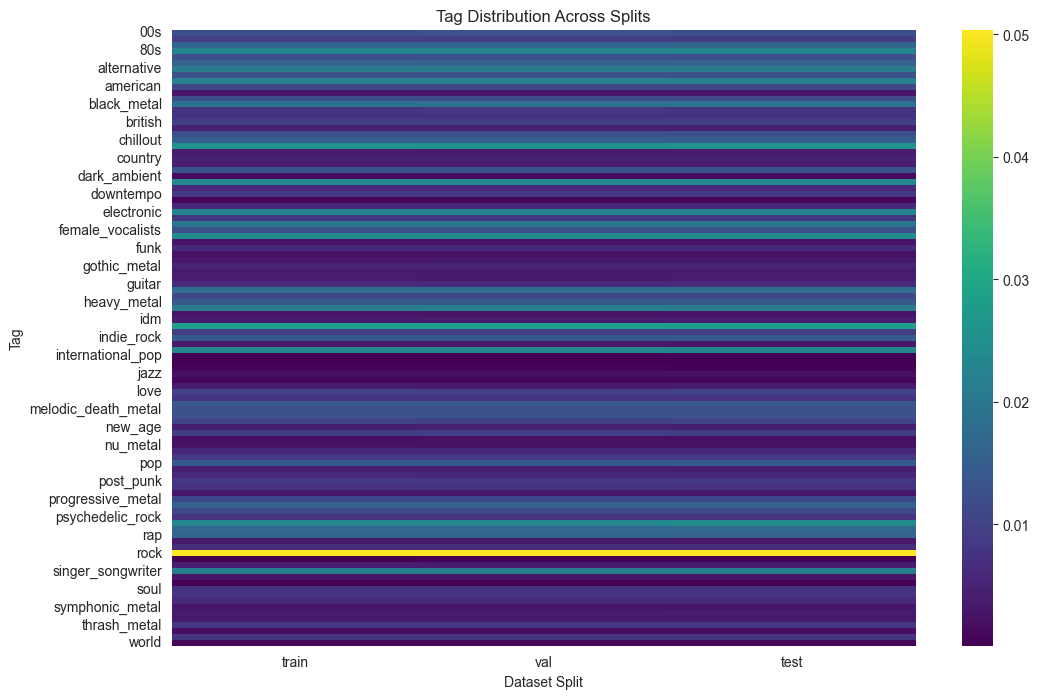

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    dist_df,
    cmap='viridis'
)

plt.title('Tag Distribution Across Splits')

plt.xlabel('Dataset Split')
plt.ylabel('Tag')

plt.show()

<Figure size 1200x600 with 0 Axes>

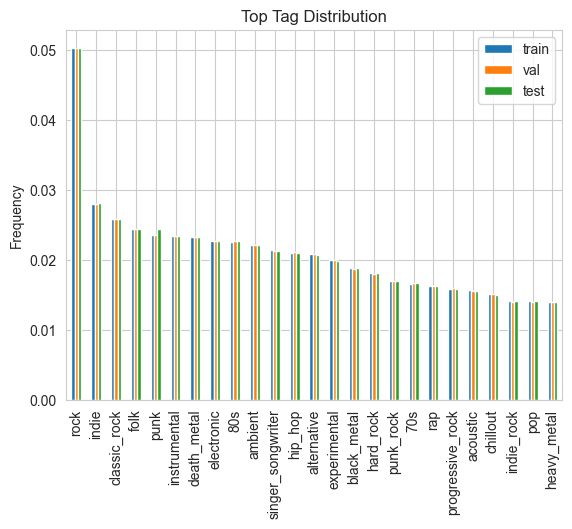

In [58]:
# plot top tags
top_tags = dist_df.sum(axis=1).sort_values(ascending=False).head(25).index

plt.figure(figsize=(12,6))

dist_df.loc[top_tags].plot(kind="bar")

plt.title("Top Tag Distribution")
plt.ylabel("Frequency")

plt.show()